# Fraud Detection in Financial Transactions (End-to-End ML Project)
## Author: Nicodimus Munyuki
This notebook builds a fraud detection system using ML with EDA, feature engineering, XGBoost tuning, and SHAP explainability.

## Problem Statement
Detect fraudulent transactions in a highly imbalanced financial dataset using machine learning.

In [1]:
!pip install xgboost

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import shap
import warnings
warnings.filterwarnings('ignore')


In [3]:

# Load dataset
df = pd.read_csv("Synthetic financial fraud.csv")
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


##  Exploratory Data Analysis (EDA)

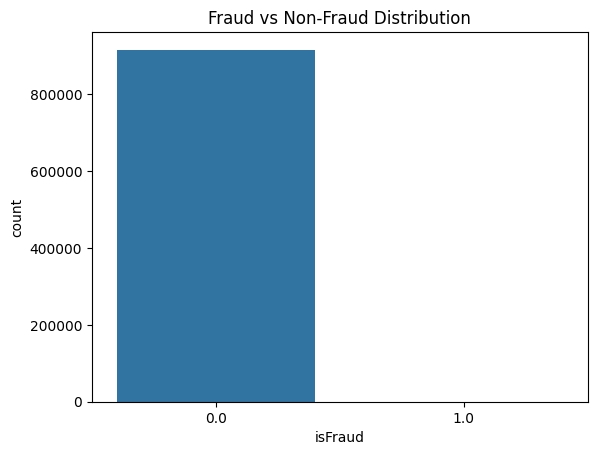

In [4]:

# Fraud distribution
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()


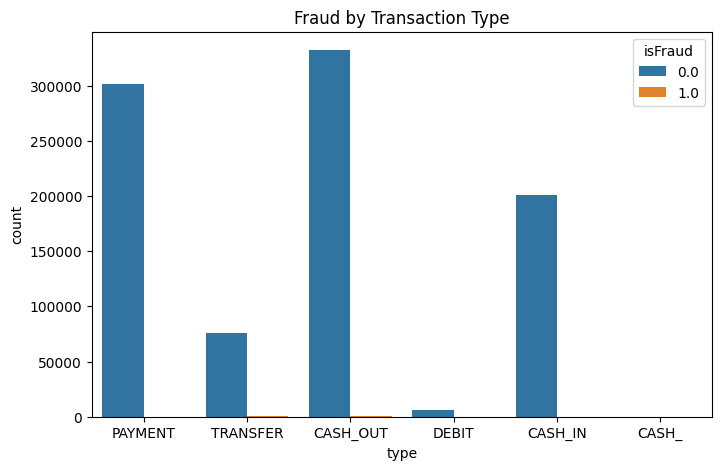

In [5]:

# Transaction type vs fraud
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='type', hue='isFraud')
plt.title("Fraud by Transaction Type")
plt.show()


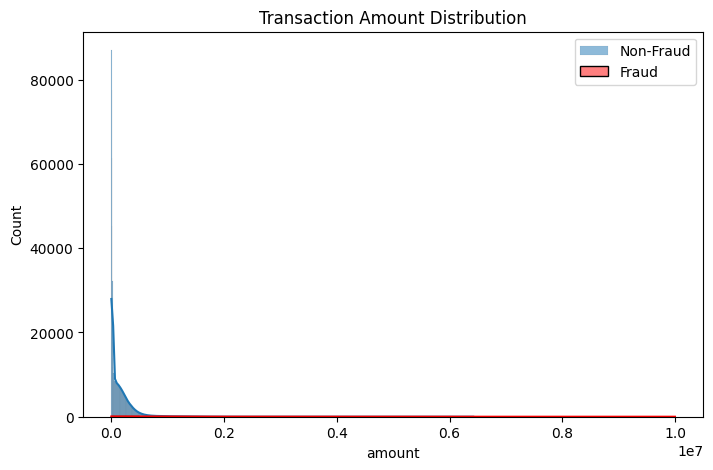

In [6]:

# Amount distribution
plt.figure(figsize=(8,5))
sns.histplot(df[df['isFraud']==0]['amount'], label='Non-Fraud', kde=True)
sns.histplot(df[df['isFraud']==1]['amount'], label='Fraud', color='red', kde=True)
plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()


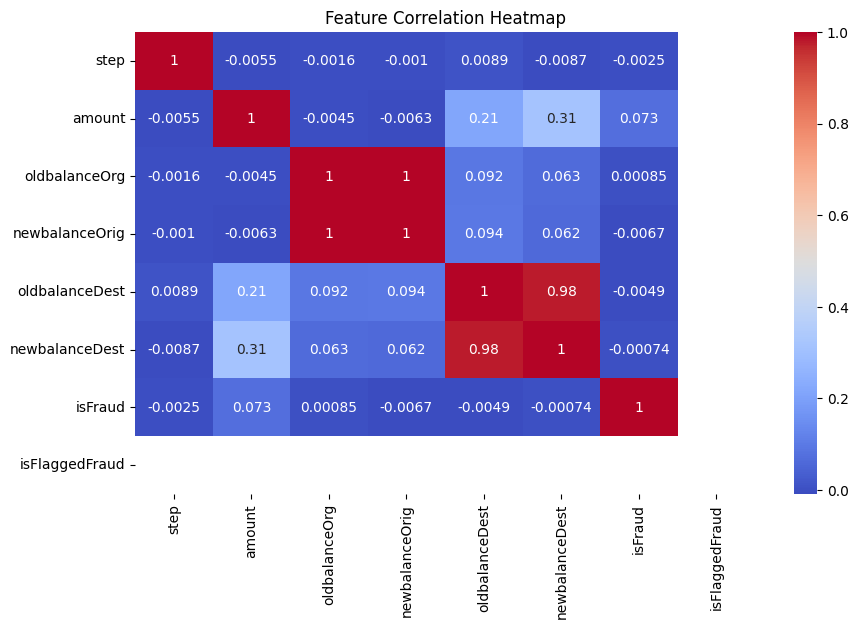

In [7]:

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()


## Feature Engineering

In [8]:

df = df.copy()

# Balance error features
df['orig_balance_error'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df['dest_balance_error'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']

# Drop leakage-prone raw IDs
df = df.drop(['nameOrig', 'nameDest'], axis=1, errors='ignore')

# 3. One-hot encode categorical 'type' column
df = pd.get_dummies(df, columns=['type'], drop_first=True)

## Train-Test Split

In [9]:
df = df.dropna(subset=['isFraud'])

# Define features (X) and target (y)
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# Perform the split with stratification
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Baseline Model (Logistic Regression)

In [10]:

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print(classification_report(y_test, pred))


              precision    recall  f1-score   support

         0.0       1.00      0.91      0.95    183127
         1.0       0.01      0.95      0.01       100

    accuracy                           0.91    183227
   macro avg       0.50      0.93      0.48    183227
weighted avg       1.00      0.91      0.95    183227



# Random Forest Model

In [11]:

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    183127
         1.0       1.00      0.96      0.98       100

    accuracy                           1.00    183227
   macro avg       1.00      0.98      0.99    183227
weighted avg       1.00      1.00      1.00    183227



# XGBoost + Hyperparameter Tuning

In [12]:

scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=8,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

pred_xgb = best_model.predict(X_test)

print("Best Params:", search.best_params_)
print(classification_report(y_test, pred_xgb))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    183127
         1.0       0.57      0.96      0.72       100

    accuracy                           1.00    183227
   macro avg       0.79      0.98      0.86    183227
weighted avg       1.00      1.00      1.00    183227



# Model Explainability (SHAP)

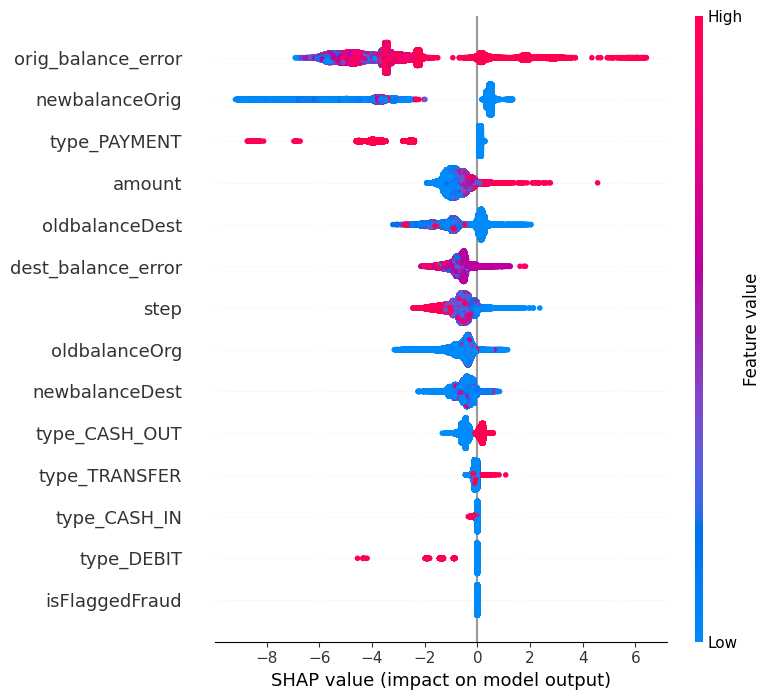

In [13]:

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


# Conclusion
- XGBoost outperforms baseline models
- Feature engineering improves signal quality
- SHAP provides interpretability for fraud detection
- Model is suitable for real-world deployment scenarios